# Hard active inverse-optimization research protocol

This permanently executed notebook demonstrates the new scientific benchmark with the built-in **uniform-random sequential-incenter** baseline. The linear objective remains $F_\theta(s,x)=(s\odot\theta)^T x$; difficulty comes from coupled decisions, limited information, small decision boundaries, partial feedback, and behavior-calibrated noise.

The notebook uses one seed and eight interactions only so it renders quickly. Publication experiments should use the default five seeds and horizon 40. Clean cases require three consecutive zero-validation-regret rounds before stopping. Stochastic cases always run to the horizon. Final curves use a separate hidden test stream, never the validation stream.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root / 'src'))

from invoptlab.active import (
    ActiveResearchConfig,
    UniformRandomIncenterAlgorithm,
    build_active_research_scenarios,
    run_active_research_benchmark,
)

plt.style.use('seaborn-v0_8-whitegrid')
protocol = ActiveResearchConfig(
    seeds=(0,), horizon=8, candidate_count=16,
    validation_query_count=16, test_query_count=32,
    consecutive_validation_successes=3,
)
protocol.to_dict()

{'seeds': [0],
 'horizon': 8,
 'candidate_count': 16,
 'validation_query_count': 16,
 'test_query_count': 32,
 'validation_seed': 40001,
 'test_seed': 90001,
 'consecutive_validation_successes': 3,
 'zero_regret_tolerance': 1e-08,
 'learning_regret_threshold': 0.01}

## What is being tested

Only the first family is intentionally easy. Every other row isolates one meaningful difficulty instead of forming an uninterpretable Cartesian product.

In [2]:
scenarios = build_active_research_scenarios(protocol)
scenario_table = pd.DataFrame([
    {
        'family': s.metadata['research_family'],
        'role': s.metadata['role'],
        'stochastic': s.metadata['stochastic'],
        'decision space': s.decision_space.kind.value,
        'query space': s.query_space.kind.value,
        'reason': s.metadata['rationale'],
    } for s in scenarios
])
scenario_table

,family,role,stochastic,decision space,query space,reason
0,easy-independent,sanity-check,False,independent_binary,dense,Separable easy control; verifies implementatio...
1,cardinality-coupled,research,False,fixed_cardinality,balanced,Selecting exactly half the items reveals ranki...
2,knapsack-coupled,research,False,structured,balanced,A resource budget couples items with unequal w...
3,dag-path-coupled,research,False,structured,balanced,Each observation compares complete source-to-s...
4,continuous-simplex,research,False,continuous_polytope,balanced,A simplex equality creates a genuinely coupled...
5,sparse-queries,research,False,fixed_cardinality,sparse,Each interaction probes only two parameter coo...
6,rare-informative,research,False,fixed_cardinality,rare_informative,Most allowed queries lie in a low-dimensional ...
7,small-margin-boundary,research,False,fixed_cardinality,sharp_boundary,Queries are paired across nearby decision boun...
8,partial-feedback,research,True,fixed_cardinality,balanced,Half of the response coordinates are hidden on...
9,behavioral-observation-noise,research,True,fixed_cardinality,balanced,Noise strength is calibrated to alter about 15...


## Run the same algorithm on all families

The algorithm receives only previous $(S,Y)$ observations, the public feasible-decision problem, and the permitted query candidates. It never receives $X$, $\theta^*$, validation/test queries, or any regret value.

In [3]:
result, research_summary = run_active_research_benchmark(
    {'uniform-incenter': lambda: UniformRandomIncenterAlgorithm(alternative_budget=64)},
    protocol,
    fail_fast=False,
)
estimate_failures = [run for run in result.runs if not run.evaluation['final_estimate_valid']]
print(f'execution completed={len(result.successful_runs)}, execution errors={len(result.failed_runs)}')
print(f'successful estimates={len(result.runs) - len(estimate_failures)}, failed estimates={len(estimate_failures)}')
assert not result.failed_runs
assert all(run.evaluation['metadata']['independent_from_stopping'] for run in result.runs)

execution completed=12, execution errors=0
successful estimates=9, failed estimates=3


In [4]:
final_rows = []
for run in result.runs:
    ev = run.evaluation
    final_rows.append({
        'family': run.scenario.metadata['research_family'],
        'steps': len(run.records),
        'stochastic': run.scenario.metadata['stochastic'],
        'status': 'SUCCESS' if ev['final_estimate_valid'] else 'FAILED',
        'failure type': None if ev['final_estimate_valid'] else ev['final_status'],
        'failure reason': ev['final_failure_reason'],
        'final regret': ev['final_normalized_regret'],
        'zero-regret rate': ev['final_zero_regret_rate'],
        'angular error (deg)': ev['final_angular_error_degrees'],
        'first regret <= 0.01': ev['first_threshold_step'],
        'stable regret <= 0.01': ev['stable_threshold_step'],
        'stopping reason': run.metadata['stopping_reason'] or 'fixed horizon',
    })
final_table = pd.DataFrame(final_rows).sort_values('final regret', ascending=False)
final_table.round(4)

,family,steps,stochastic,status,failure type,failure reason,final regret,zero-regret rate,angular error (deg),first regret <= 0.01,stable regret <= 0.01,stopping reason
5,sparse-queries,8,False,SUCCESS,None,None,0.1764,0.5625,38.3490,NaN,NaN,fixed horizon
4,continuous-simplex,8,False,SUCCESS,None,None,0.1187,0.3750,40.0089,NaN,NaN,fixed horizon
3,dag-path-coupled,8,False,SUCCESS,None,None,0.1158,0.6250,33.5917,NaN,NaN,fixed horizon
7,small-margin-boundary,8,False,SUCCESS,None,None,0.0649,0.1562,29.2305,NaN,NaN,fixed horizon
6,rare-informative,8,False,SUCCESS,None,None,0.0249,0.6250,25.0193,NaN,NaN,fixed horizon
9,behavioral-observation-noise,8,True,SUCCESS,None,None,0.0034,0.8125,11.5855,4.0,4.0,fixed horizon
1,cardinality-coupled,8,False,SUCCESS,None,None,0.0034,0.8125,11.5855,4.0,4.0,fixed horizon
2,knapsack-coupled,3,False,SUCCESS,None,None,0.0001,0.9688,2.1313,1.0,1.0,zero validation regret for 3 consecutive steps
0,easy-independent,3,False,SUCCESS,None,None,0.0000,1.0000,2.1313,1.0,1.0,zero validation regret for 3 consecutive steps
8,partial-feedback,8,True,FAILED,insufficient_information,the complete observed decision is unavailable,NaN,NaN,NaN,NaN,NaN,fixed horizon


## Regret at every interaction

Every panel below is a complete test-regret trajectory, not only a final value. The dashed line is the protocol's 0.01 learning threshold. A missing point means the estimator explicitly failed; no artificial regret is computed for an invalid estimate.

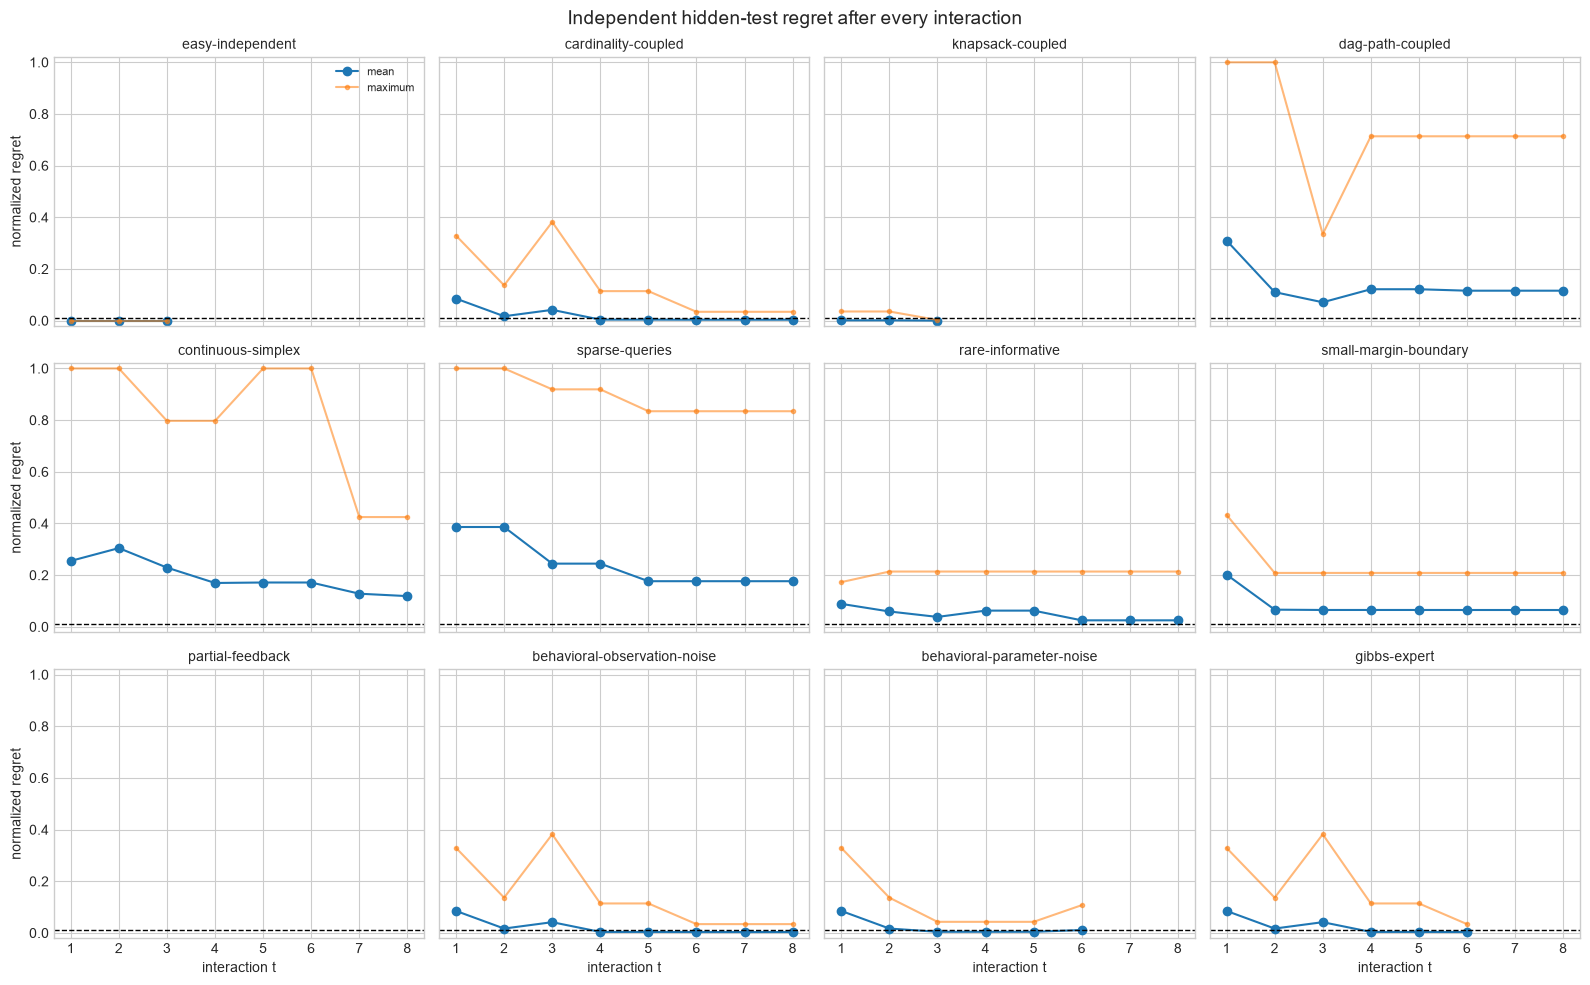

In [5]:
trajectory_rows = []
for run in result.runs:
    ev = run.evaluation
    for i, record in enumerate(run.records):
        trajectory_rows.append({
            'family': run.scenario.metadata['research_family'],
            'step': record.step,
            'status': ev['estimate_status_history'][i],
            'regret': ev['normalized_regret_history'][i],
            'max regret': ev['maximum_normalized_regret_history'][i],
            'zero-regret rate': ev['zero_regret_rate_history'][i],
            'angular error': ev['angular_error_history_degrees'][i],
            'constraints': record.update_diagnostics.get('constraint_count', 0),
            'inradius': record.update_diagnostics.get('incenter_radius', 0.0),
        })
trajectory = pd.DataFrame(trajectory_rows)
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
for axis, (family, frame) in zip(axes.flat, trajectory.groupby('family', sort=False)):
    axis.plot(frame['step'], frame['regret'], marker='o', label='mean')
    axis.plot(frame['step'], frame['max regret'], marker='.', alpha=.55, label='maximum')
    axis.axhline(protocol.learning_regret_threshold, color='black', ls='--', lw=1)
    axis.set_title(family, fontsize=10)
    axis.set_ylim(-.02, 1.02)
for axis in axes[-1]: axis.set_xlabel('interaction t')
for axis in axes[:, 0]: axis.set_ylabel('normalized regret')
axes[0, 0].legend(fontsize=8)
fig.suptitle('Independent hidden-test regret after every interaction', fontsize=14)
fig.tight_layout()
plt.show()

## Parameter recovery and behavioral correctness through time

These measurements answer different questions. Angular error measures recovery of $\theta^*$; zero-regret rate measures how often the estimate induces exactly the correct test decision. Failed estimates are left blank rather than being displayed as 90 or 180 degrees.

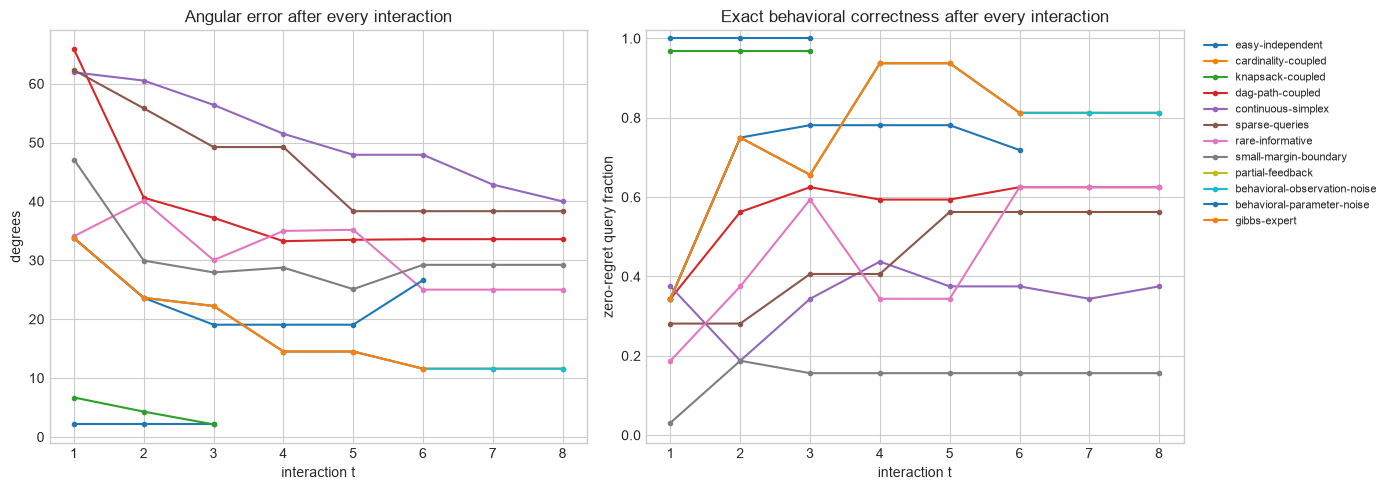

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for family, frame in trajectory.groupby('family', sort=False):
    axes[0].plot(frame['step'], frame['angular error'], marker='.', label=family)
    axes[1].plot(frame['step'], frame['zero-regret rate'], marker='.', label=family)
axes[0].set(title='Angular error after every interaction', xlabel='interaction t', ylabel='degrees')
axes[1].set(title='Exact behavioral correctness after every interaction', xlabel='interaction t', ylabel='zero-regret query fraction', ylim=(-.02, 1.02))
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

## Cone estimator evolution at every interaction

The research dimensions exceed three, so a geometric cone drawing would be misleading. Instead, the two quantities available in every dimension—the number of consistency hyperplanes and normalized inradius—are plotted at every time step.

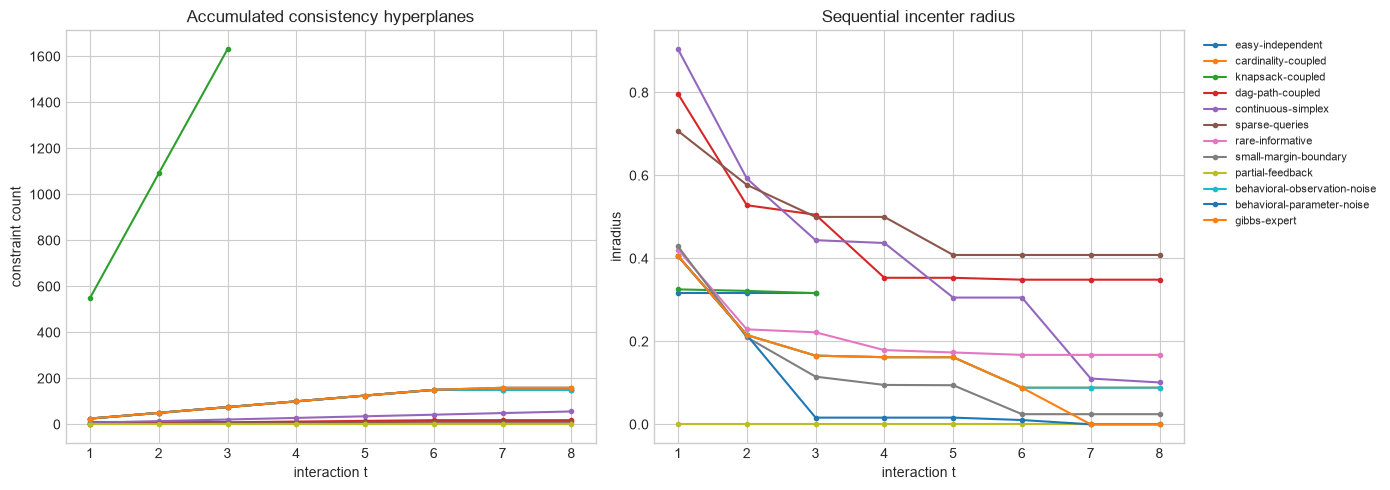

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for family, frame in trajectory.groupby('family', sort=False):
    axes[0].plot(frame['step'], frame['constraints'], marker='.', label=family)
    axes[1].plot(frame['step'], frame['inradius'], marker='.', label=family)
axes[0].set(title='Accumulated consistency hyperplanes', xlabel='interaction t', ylabel='constraint count')
axes[1].set(title='Sequential incenter radius', xlabel='interaction t', ylabel='inradius')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

## Noise calibration and stopping audit

Calibration reports the empirical probability of changing the expert's decision, which is more interpretable than a raw $\sigma$. The stopping audit shows that stochastic families use the fixed horizon and clean families require sustained validation success.

In [8]:
calibration_rows = []
stopping_rows = []
for run in result.runs:
    family = run.scenario.metadata['research_family']
    for channel, values in run.metadata.get('noise_calibration', {}).items():
        calibration_rows.append({'family': family, 'channel': channel, **values})
    stopping_rows.append({
        'family': family,
        'stochastic': run.scenario.metadata['stochastic'],
        'executed steps': len(run.records),
        'external stopping enabled': run.metadata['external_stopping_enabled'],
        'criterion met': run.metadata['stopping_criterion_met'],
        'reason': run.metadata['stopping_reason'] or 'fixed horizon',
    })
print('Behavioral calibration')
display(pd.DataFrame(calibration_rows).round(4))
print('Stopping audit')
display(pd.DataFrame(stopping_rows))

Behavioral calibration


,family,channel,target_change_rate,achieved_change_rate,effective_strength,trials
0,behavioral-observation-noise,local_observation,0.15,0.125,0.4380,64
1,behavioral-parameter-noise,isotropic_parameter,0.15,0.125,0.0737,64


Stopping audit


,family,stochastic,executed steps,external stopping enabled,criterion met,reason
0,easy-independent,False,3,True,True,zero validation regret for 3 consecutive steps
1,cardinality-coupled,False,8,True,False,fixed horizon
2,knapsack-coupled,False,3,True,True,zero validation regret for 3 consecutive steps
3,dag-path-coupled,False,8,True,False,fixed horizon
4,continuous-simplex,False,8,True,False,fixed horizon
5,sparse-queries,False,8,True,False,fixed horizon
6,rare-informative,False,8,True,False,fixed horizon
7,small-margin-boundary,False,8,True,False,fixed horizon
8,partial-feedback,True,8,False,False,fixed horizon
9,behavioral-observation-noise,True,8,False,False,fixed horizon


## How to use the result

The easy independent-binary row is only a correctness check. Research conclusions should come from the other eleven families and from several seeds. A good active algorithm should improve the coupled and information-limited trajectories, not merely reproduce the easy sign pattern. A nonzero angular error with zero regret is possible and should be reported honestly: it means the behavior was identified more precisely than the numerical parameter direction.